In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ All imports successful")

✅ All imports successful


In [2]:
# --------------------------------------------------
# Load data  (adjust paths if needed)
# --------------------------------------------------
train = pd.read_csv('../../../data/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
store = pd.read_csv('../../../data/rossmann-store-sales/store.csv')

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
# Merge store metadata
train = train.merge(store, on='Store', how='left')

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
# Basic cleaning
train = train[train['Open'] == 1]          # keep only open days
train = train[train['Sales'] > 0]          # remove zero-sales rows
train.sort_values('Date', inplace=True)
train.reset_index(drop=True, inplace=True)

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,NaN,NaN,NaN
1,494,2,2013-01-01,3113,527,1,0,a,1,b,a,1260.0,6.0,2011.0,0,NaN,NaN,NaN
2,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,NaN,NaN,NaN
3,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9.0,2006.0,0,NaN,NaN,NaN
4,676,2,2013-01-01,3821,777,1,0,a,1,b,b,1410.0,9.0,2008.0,0,NaN,NaN,NaN


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  object        
 10  Assortment                 844338 non-null  object        
 11  CompetitionDistance        842152 non-null  float64 

In [10]:
train.drop(columns=["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"], inplace=True)

In [12]:
train['CompetitionDistance'].describe()

count    844338.000000
mean       5450.031907
std        7801.087197
min          20.000000
25%         710.000000
50%        2320.000000
75%        6880.000000
max       75860.000000
Name: CompetitionDistance, dtype: float64

In [13]:
# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Competition distance bucketed
train['CompetitionDistance'] = train['CompetitionDistance'].fillna(train['CompetitionDistance'].median())
train['CompDistBucket'] = pd.cut(train['CompetitionDistance'],
                                  bins=[0,500,1500,4000,6000,np.inf],
                                  labels=[0,1,2,3,4]).astype(float)

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,CompDistBucket
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,1.0
1,494,2,2013-01-01,3113,527,1,0,a,1,b,a,1260.0,6.0,2011.0,0,1.0
2,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,1.0
3,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9.0,2006.0,0,0.0
4,676,2,2013-01-01,3821,777,1,0,a,1,b,b,1410.0,9.0,2008.0,0,1.0


In [16]:
# 2. StoreType & Assortment encoded
le = LabelEncoder()
train['StoreTypeEnc']  = le.fit_transform(train['StoreType'].fillna('a'))
train['AssortmentEnc'] = le.fit_transform(train['Assortment'].fillna('a'))


train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,CompDistBucket,StoreTypeEnc,AssortmentEnc
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,1.0,1,1
1,494,2,2013-01-01,3113,527,1,0,a,1,b,a,1260.0,6.0,2011.0,0,1.0,1,0
2,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,1.0,1,1
3,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,1,0
4,676,2,2013-01-01,3821,777,1,0,a,1,b,b,1410.0,9.0,2008.0,0,1.0,1,1


In [18]:
# 3. Competition open months
train['CompetitionOpenSinceDate'] = pd.to_datetime(
    dict(year=train['CompetitionOpenSinceYear'],
         month=train['CompetitionOpenSinceMonth'],
         day=1), errors='coerce')
train['CompOpenMonths'] = ((train['Date'] - train['CompetitionOpenSinceDate'])
                            .dt.days / 30).clip(lower=0).fillna(0)

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,CompDistBucket,StoreTypeEnc,AssortmentEnc,CompetitionOpenSinceDate,CompOpenMonths
0,1097,2,2013-01-01,5961,1405,1,0,a,1,b,b,720.0,3.0,2002.0,0,1.0,1,1,2002-03-01,131.966667
1,494,2,2013-01-01,3113,527,1,0,a,1,b,a,1260.0,6.0,2011.0,0,1.0,1,0,2011-06-01,19.333333
2,733,2,2013-01-01,10765,2377,1,0,a,1,b,b,860.0,10.0,1999.0,0,1.0,1,1,1999-10-01,161.366667
3,682,2,2013-01-01,3375,566,1,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,1,0,2006-09-01,77.133333
4,676,2,2013-01-01,3821,777,1,0,a,1,b,b,1410.0,9.0,2008.0,0,1.0,1,1,2008-09-01,52.766667


In [19]:
# 4. Day / Week / Month features
train['DayOfWeek']  = train['Date'].dt.dayofweek
train['WeekOfYear'] = train['Date'].dt.isocalendar().week.astype(int)
train['Month']      = train['Date'].dt.month
train['IsWeekend']  = (train['DayOfWeek'] >= 5).astype(int)

print(f"Shape after feature engineering: {train.shape}")
train.head(3)

Shape after feature engineering: (844338, 23)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,CompDistBucket,StoreTypeEnc,AssortmentEnc,CompetitionOpenSinceDate,CompOpenMonths,WeekOfYear,Month,IsWeekend
0,1097,1,2013-01-01,5961,1405,1,0,a,1,b,...,2002.0,0,1.0,1,1,2002-03-01,131.966667,1,1,0
1,494,1,2013-01-01,3113,527,1,0,a,1,b,...,2011.0,0,1.0,1,0,2011-06-01,19.333333,1,1,0
2,733,1,2013-01-01,10765,2377,1,0,a,1,b,...,1999.0,0,1.0,1,1,1999-10-01,161.366667,1,1,0


In [20]:
STORE_ID = 1

REGRESSORS = [
    'Promo', 'Promo2', 'SchoolHoliday',
    'CompDistBucket', 'StoreTypeEnc', 'AssortmentEnc',
    'CompOpenMonths', 'IsWeekend', 'StateHoliday'
]

df = train[train['Store'] == STORE_ID].copy()
df['StateHoliday'] = (df['StateHoliday'] != '0').astype(int)

prophet_df = df[['Date', 'Sales'] + REGRESSORS].copy()
prophet_df.rename(columns={'Date': 'ds', 'Sales': 'y'}, inplace=True)
prophet_df.sort_values('ds', inplace=True)
prophet_df.reset_index(drop=True, inplace=True)

# Fill any nulls in regressors
for col in REGRESSORS:
    prophet_df[col] = prophet_df[col].fillna(0)

print(f"Date range : {prophet_df['ds'].min()}  →  {prophet_df['ds'].max()}")
print(f"Rows       : {len(prophet_df)}")
print(f"Regressors : {REGRESSORS}")
prophet_df.head(3)

Date range : 2013-01-02 00:00:00  →  2015-07-31 00:00:00
Rows       : 781
Regressors : ['Promo', 'Promo2', 'SchoolHoliday', 'CompDistBucket', 'StoreTypeEnc', 'AssortmentEnc', 'CompOpenMonths', 'IsWeekend', 'StateHoliday']


,ds,y,Promo,Promo2,SchoolHoliday,CompDistBucket,StoreTypeEnc,AssortmentEnc,CompOpenMonths,IsWeekend,StateHoliday
0,2013-01-02,5530,0,0,1,1.0,2,0,52.800000,0,0
1,2013-01-03,4327,0,0,1,1.0,2,0,52.833333,0,0
2,2013-01-04,4486,0,0,1,1.0,2,0,52.866667,0,0


In [21]:
from prophet.make_holidays import make_holidays_df

# Built-in German holidays via Prophet
german_holidays = make_holidays_df(year_list=list(range(2013, 2016)), country='DE')

# Add Rossmann-specific "StateHoliday" events from the data itself
state_hol_dates = prophet_df[prophet_df['StateHoliday'] == 1]['ds']
custom_holidays = pd.DataFrame({
    'holiday'   : 'state_holiday',
    'ds'        : state_hol_dates,
    'lower_window': -1,
    'upper_window':  1,
})

all_holidays = pd.concat([german_holidays, custom_holidays]).drop_duplicates('ds')
print(f"Total holiday rows: {len(all_holidays)}")
all_holidays.head(6)

Total holiday rows: 27


,ds,holiday,lower_window,upper_window
0,2013-01-01,New Year's Day,NaN,NaN
1,2013-03-29,Good Friday,NaN,NaN
2,2013-04-01,Easter Monday,NaN,NaN
3,2013-05-01,Labor Day,NaN,NaN
4,2013-05-09,Ascension Day,NaN,NaN
5,2013-05-20,Whit Monday,NaN,NaN


In [30]:
VALIDATION_WEEKS = 6

split_date = prophet_df['ds'].max() - pd.Timedelta(weeks=VALIDATION_WEEKS)
train_df   = prophet_df[prophet_df['ds'] <= split_date].copy()
val_df     = prophet_df[prophet_df['ds'] >  split_date].copy()

print(f"Train : {len(train_df)} rows  |  {train_df['ds'].min()} → {train_df['ds'].max()}")
print(f"Val   : {len(val_df)}  rows  |  {val_df['ds'].min()}  → {val_df['ds'].max()}")

Train : 745 rows  |  2013-01-02 00:00:00 → 2015-06-19 00:00:00
Val   : 36  rows  |  2015-06-20 00:00:00  → 2015-07-31 00:00:00


In [31]:
def evaluate(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual > 0
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
    rmspe = np.sqrt(np.mean(((actual[mask] - predicted[mask]) / actual[mask]) ** 2)) * 100
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE%': round(mape,2), 'RMSPE%': round(rmspe,2)}

In [32]:
def build_and_evaluate(params, train_data, val_data, holidays, regressors, verbose=False):
    """
    Builds a Prophet model with the given params dict, fits on train_data,
    and returns (metrics_dict, forecast_df).
    """
    m = Prophet(
        changepoint_prior_scale   = params['changepoint_prior_scale'],
        seasonality_prior_scale   = params['seasonality_prior_scale'],
        holidays_prior_scale      = params['holidays_prior_scale'],
        seasonality_mode          = params['seasonality_mode'],
        changepoint_range         = params['changepoint_range'],
        yearly_seasonality        = params['yearly_seasonality'],
        weekly_seasonality        = params['weekly_seasonality'],
        daily_seasonality         = False,
        holidays                  = holidays,
        interval_width            = 0.95,
    )

    # Custom Fourier seasonalities
    if params.get('add_monthly'):
        m.add_seasonality(name='monthly', period=30.5,
                          fourier_order=params['monthly_fourier_order'])
    if params.get('add_quarterly'):
        m.add_seasonality(name='quarterly', period=91.25,
                          fourier_order=params['quarterly_fourier_order'])

    # Regressors
    selected = params.get('regressors', regressors)
    for reg in selected:
        m.add_regressor(reg)

    m.fit(train_data)

    # Forecast
    future   = m.make_future_dataframe(periods=len(val_data))
    # Fill regressor values for future dates
    future   = future.merge(
        pd.concat([train_data, val_data])[['ds'] + selected],
        on='ds', how='left'
    )
    future[selected] = future[selected].fillna(0)

    forecast = m.predict(future)
    pred_val = forecast[forecast['ds'].isin(val_data['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
    merged   = val_data[['ds','y']].merge(pred_val, on='ds')

    metrics = evaluate(merged['y'].values, merged['yhat'].values)
    if verbose:
        print(f"  → MAE={metrics['MAE']}  RMSE={metrics['RMSE']}  MAPE={metrics['MAPE%']}%  RMSPE={metrics['RMSPE%']}%")

    return metrics, forecast, m

In [33]:
import random

random.seed(42)
np.random.seed(42)

# ── Parameter Grid ─────────────────────────────────────────────────────────
param_grid = {
    'changepoint_prior_scale' : [0.01, 0.05, 0.1, 0.3, 0.5],
    'seasonality_prior_scale' : [0.1, 1.0, 5.0, 10.0],
    'holidays_prior_scale'    : [1.0, 5.0, 10.0],
    'seasonality_mode'        : ['additive', 'multiplicative'],
    'changepoint_range'       : [0.8, 0.9],
    'yearly_seasonality'      : [5, 10, 20],
    'weekly_seasonality'      : [3, 7],
    'add_monthly'             : [True, False],
    'monthly_fourier_order'   : [3, 5],
    'add_quarterly'           : [True, False],
    'quarterly_fourier_order' : [3, 5],
}

REGRESSOR_SUBSETS = {
    'all'          : REGRESSORS,
    'promo_only'   : ['Promo', 'Promo2',],
    'core'         : ['Promo', 'SchoolHoliday', 'StateHoliday', 'IsWeekend'],
    'no_regressors': [],
}

# ── Build full combo list & random sample ──────────────────────────────────
keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))

N_SAMPLES       = 100   # per regressor set  →  100 × 4 = 400 total
sampled_combos  = random.sample(combos, min(N_SAMPLES, len(combos)))

total = N_SAMPLES * len(REGRESSOR_SUBSETS)
print(f"Full grid size : {len(combos) * len(REGRESSOR_SUBSETS):,}")
print(f"Evaluating     : {total}  (random sample, seed=42)")

# ── Run ────────────────────────────────────────────────────────────────────
results = []
count   = 0

for reg_name, reg_list in REGRESSOR_SUBSETS.items():
    for combo in sampled_combos:
        params = dict(zip(keys, combo))
        params['regressors'] = reg_list

        try:
            metrics, _, _ = build_and_evaluate(
                params, train_df, val_df, all_holidays, reg_list
            )
            metrics['regressor_set'] = reg_name
            metrics.update({k: v for k, v in params.items() if k != 'regressors'})
            results.append(metrics)
        except Exception:
            pass

        count += 1
        if count % 50 == 0:
            best_so_far = min(r['MAPE%'] for r in results) if results else 999
            print(f"  [{count}/{total}]  best MAPE so far: {best_so_far:.2f}%")

results_df = pd.DataFrame(results).sort_values('MAPE%').reset_index(drop=True)
print(f"\n✅ Done!  Best MAPE: {results_df['MAPE%'].iloc[0]:.2f}%")
results_df.head(10)

Full grid size : 92,160
Evaluating     : 400  (random sample, seed=42)


11:49:07 - cmdstanpy - INFO - Chain [1] start processing
11:49:08 - cmdstanpy - INFO - Chain [1] done processing
11:49:08 - cmdstanpy - INFO - Chain [1] start processing
11:49:08 - cmdstanpy - INFO - Chain [1] done processing
11:49:08 - cmdstanpy - INFO - Chain [1] start processing
11:49:08 - cmdstanpy - INFO - Chain [1] done processing
11:49:09 - cmdstanpy - INFO - Chain [1] start processing
11:49:09 - cmdstanpy - INFO - Chain [1] done processing
11:49:10 - cmdstanpy - INFO - Chain [1] start processing
11:49:10 - cmdstanpy - INFO - Chain [1] done processing
11:49:10 - cmdstanpy - INFO - Chain [1] start processing
11:49:11 - cmdstanpy - INFO - Chain [1] done processing
11:49:11 - cmdstanpy - INFO - Chain [1] start processing
11:49:11 - cmdstanpy - INFO - Chain [1] done processing
11:49:12 - cmdstanpy - INFO - Chain [1] start processing
11:49:12 - cmdstanpy - INFO - Chain [1] done processing
11:49:12 - cmdstanpy - INFO - Chain [1] start processing
11:49:13 - cmdstanpy - INFO - Chain [1]

  [50/400]  best MAPE so far: 5.86%


11:49:44 - cmdstanpy - INFO - Chain [1] done processing
11:49:45 - cmdstanpy - INFO - Chain [1] start processing
11:49:45 - cmdstanpy - INFO - Chain [1] done processing
11:49:46 - cmdstanpy - INFO - Chain [1] start processing
11:49:46 - cmdstanpy - INFO - Chain [1] done processing
11:49:46 - cmdstanpy - INFO - Chain [1] start processing
11:49:46 - cmdstanpy - INFO - Chain [1] done processing
11:49:47 - cmdstanpy - INFO - Chain [1] start processing
11:49:47 - cmdstanpy - INFO - Chain [1] done processing
11:49:47 - cmdstanpy - INFO - Chain [1] start processing
11:49:47 - cmdstanpy - INFO - Chain [1] done processing
11:49:48 - cmdstanpy - INFO - Chain [1] start processing
11:49:48 - cmdstanpy - INFO - Chain [1] done processing
11:49:49 - cmdstanpy - INFO - Chain [1] start processing
11:49:49 - cmdstanpy - INFO - Chain [1] done processing
11:49:50 - cmdstanpy - INFO - Chain [1] start processing
11:49:50 - cmdstanpy - INFO - Chain [1] done processing
11:49:50 - cmdstanpy - INFO - Chain [1] 

  [100/400]  best MAPE so far: 5.86%


...

11:52:32 - cmdstanpy - INFO - Chain [1] done processing
11:52:33 - cmdstanpy - INFO - Chain [1] start processing
11:52:33 - cmdstanpy - INFO - Chain [1] done processing
11:52:33 - cmdstanpy - INFO - Chain [1] start processing
11:52:33 - cmdstanpy - INFO - Chain [1] done processing
11:52:34 - cmdstanpy - INFO - Chain [1] start processing
11:52:34 - cmdstanpy - INFO - Chain [1] done processing
11:52:35 - cmdstanpy - INFO - Chain [1] start processing
11:52:35 - cmdstanpy - INFO - Chain [1] done processing
11:52:35 - cmdstanpy - INFO - Chain [1] start processing
11:52:35 - cmdstanpy - INFO - Chain [1] done processing
11:52:36 - cmdstanpy - INFO - Chain [1] start processing
11:52:36 - cmdstanpy - INFO - Chain [1] done processing
11:52:36 - cmdstanpy - INFO - Chain [1] start processing
11:52:36 - cmdstanpy - INFO - Chain [1] done processing
11:52:37 - cmdstanpy - INFO - Chain [1] start processing
11:52:38 - cmdstanpy - INFO - Chain [1] done processing
11:52:38 - cmdstanpy - INFO - Chain [1] 

  [350/400]  best MAPE so far: 5.56%


11:53:00 - cmdstanpy - INFO - Chain [1] done processing
11:53:00 - cmdstanpy - INFO - Chain [1] start processing
11:53:00 - cmdstanpy - INFO - Chain [1] done processing
11:53:01 - cmdstanpy - INFO - Chain [1] start processing
11:53:01 - cmdstanpy - INFO - Chain [1] done processing
11:53:01 - cmdstanpy - INFO - Chain [1] start processing
11:53:01 - cmdstanpy - INFO - Chain [1] done processing
11:53:02 - cmdstanpy - INFO - Chain [1] start processing
11:53:02 - cmdstanpy - INFO - Chain [1] done processing
11:53:02 - cmdstanpy - INFO - Chain [1] start processing
11:53:03 - cmdstanpy - INFO - Chain [1] done processing
11:53:03 - cmdstanpy - INFO - Chain [1] start processing
11:53:03 - cmdstanpy - INFO - Chain [1] done processing
11:53:04 - cmdstanpy - INFO - Chain [1] start processing
11:53:04 - cmdstanpy - INFO - Chain [1] done processing
11:53:04 - cmdstanpy - INFO - Chain [1] start processing
11:53:04 - cmdstanpy - INFO - Chain [1] done processing
11:53:04 - cmdstanpy - INFO - Chain [1] 

  [400/400]  best MAPE so far: 5.56%

✅ Done!  Best MAPE: 5.56%


,MAE,RMSE,MAPE%,RMSPE%,regressor_set,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,seasonality_mode,changepoint_range,yearly_seasonality,weekly_seasonality,add_monthly,monthly_fourier_order,add_quarterly,quarterly_fourier_order
0,237.67,326.43,5.56,7.79,promo_only,0.01,5.0,1.0,multiplicative,0.8,20,7,True,5,False,3
1,239.11,325.60,5.60,7.74,promo_only,0.01,5.0,10.0,multiplicative,0.8,20,7,True,5,True,5
2,238.92,325.56,5.60,7.77,promo_only,0.01,1.0,10.0,multiplicative,0.9,20,3,True,5,False,5
3,240.61,326.86,5.70,7.92,promo_only,0.01,5.0,1.0,multiplicative,0.9,5,7,True,5,False,3
4,247.67,334.22,5.77,7.82,core,0.10,1.0,5.0,multiplicative,0.8,20,7,True,5,True,5
5,246.56,331.54,5.83,7.88,promo_only,0.01,0.1,10.0,multiplicative,0.8,20,7,True,3,True,5
6,249.28,341.61,5.86,8.09,all,0.10,1.0,5.0,multiplicative,0.8,20,7,True,5,True,5
7,248.08,335.68,5.88,8.22,promo_only,0.10,0.1,5.0,additive,0.8,5,3,True,5,False,3
8,252.68,355.80,5.89,8.40,promo_only,0.01,5.0,5.0,multiplicative,0.9,20,7,False,5,False,3
9,252.91,356.06,5.90,8.41,promo_only,0.01,5.0,10.0,multiplicative,0.8,20,7,False,5,False,3


In [35]:
pd.DataFrame(results).sort_values('RMSPE%').reset_index(drop=True).head(10)

,MAE,RMSE,MAPE%,RMSPE%,regressor_set,changepoint_prior_scale,seasonality_prior_scale,holidays_prior_scale,seasonality_mode,changepoint_range,yearly_seasonality,weekly_seasonality,add_monthly,monthly_fourier_order,add_quarterly,quarterly_fourier_order
0,239.11,325.60,5.60,7.74,promo_only,0.01,5.0,10.0,multiplicative,0.8,20,7,True,5,True,5
1,238.92,325.56,5.60,7.77,promo_only,0.01,1.0,10.0,multiplicative,0.9,20,3,True,5,False,5
2,237.67,326.43,5.56,7.79,promo_only,0.01,5.0,1.0,multiplicative,0.8,20,7,True,5,False,3
3,247.67,334.22,5.77,7.82,core,0.10,1.0,5.0,multiplicative,0.8,20,7,True,5,True,5
4,276.30,352.97,6.30,7.84,core,0.50,10.0,5.0,multiplicative,0.8,20,7,True,5,True,5
5,253.07,327.87,6.02,7.85,promo_only,0.10,1.0,1.0,multiplicative,0.8,20,3,True,3,False,3
6,256.96,325.77,6.11,7.87,promo_only,0.05,10.0,10.0,multiplicative,0.8,20,7,True,5,True,3
7,246.56,331.54,5.83,7.88,promo_only,0.01,0.1,10.0,multiplicative,0.8,20,7,True,3,True,5
8,258.98,330.74,6.16,7.89,promo_only,0.30,10.0,10.0,multiplicative,0.9,10,7,True,5,False,3
9,260.50,334.53,6.17,7.92,core,0.30,10.0,10.0,multiplicative,0.9,10,7,True,5,False,3


In [13]:
# ── Optuna refines the search in far fewer trials ──────────────────────────
def optuna_objective(trial):
    params = {
        'changepoint_prior_scale' : trial.suggest_float('changepoint_prior_scale', 0.001, 1.0, log=True),
        'seasonality_prior_scale' : trial.suggest_float('seasonality_prior_scale', 0.01, 50.0, log=True),
        'holidays_prior_scale'    : trial.suggest_float('holidays_prior_scale', 0.01, 20.0, log=True),
        'seasonality_mode'        : trial.suggest_categorical('seasonality_mode', ['additive','multiplicative']),
        'changepoint_range'       : trial.suggest_float('changepoint_range', 0.7, 0.95),
        'yearly_seasonality'      : trial.suggest_int('yearly_seasonality', 3, 25),
        'weekly_seasonality'      : trial.suggest_int('weekly_seasonality', 3, 10),
        'add_monthly'             : trial.suggest_categorical('add_monthly', [True, False]),
        'monthly_fourier_order'   : trial.suggest_int('monthly_fourier_order', 2, 8),
        'add_quarterly'           : trial.suggest_categorical('add_quarterly', [True, False]),
        'quarterly_fourier_order' : trial.suggest_int('quarterly_fourier_order', 2, 8),
        'regressors'              : REGRESSORS,
    }
    try:
        metrics, _, _ = build_and_evaluate(params, train_df, val_df, all_holidays, REGRESSORS)
        return metrics['MAPE%']
    except:
        return 999.0

N_TRIALS = 60   # increase for better results (slower)
study    = optuna.create_study(direction='minimize')
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n✅ Optuna done!  Best MAPE: {study.best_value:.2f}%")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:35s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]

17:54:58 - cmdstanpy - INFO - Chain [1] start processing
17:54:59 - cmdstanpy - INFO - Chain [1] done processing
17:55:00 - cmdstanpy - INFO - Chain [1] start processing
17:55:01 - cmdstanpy - INFO - Chain [1] done processing
17:55:01 - cmdstanpy - INFO - Chain [1] start processing
17:55:01 - cmdstanpy - INFO - Chain [1] done processing
17:55:02 - cmdstanpy - INFO - Chain [1] start processing
17:55:02 - cmdstanpy - INFO - Chain [1] done processing
17:55:03 - cmdstanpy - INFO - Chain [1] start processing
17:55:03 - cmdstanpy - INFO - Chain [1] done processing
17:55:04 - cmdstanpy - INFO - Chain [1] start processing
17:55:04 - cmdstanpy - INFO - Chain [1] done processing
17:55:04 - cmdstanpy - INFO - Chain [1] start processing
17:55:05 - cmdstanpy - INFO - Chain [1] done processing
17:55:06 - cmdstanpy - INFO - Chain [1] start processing
17:55:06 - cmdstanpy - INFO - Chain [1] done processing
17:55:07 - cmdstanpy - INFO - Chain [1] start processing
17:55:07 - cmdstanpy - INFO - Chain [1]


✅ Optuna done!  Best MAPE: 5.54%
Best params:
  changepoint_prior_scale             = 0.016877874284002597
  seasonality_prior_scale             = 0.15733258913725626
  holidays_prior_scale                = 2.222031706228922
  seasonality_mode                    = multiplicative
  changepoint_range                   = 0.8341161463001697
  yearly_seasonality                  = 3
  weekly_seasonality                  = 3
  add_monthly                         = True
  monthly_fourier_order               = 4
  add_quarterly                       = False
  quarterly_fourier_order             = 6


In [14]:
# ── Combine grid-search best + Optuna best ─────────────────────────────────
best_grid   = results_df.iloc[0].to_dict()
best_optuna = study.best_params.copy()
best_optuna['regressors'] = REGRESSORS

# Rebuild best Optuna model
_, forecast_optuna, best_model = build_and_evaluate(
    best_optuna, train_df, val_df, all_holidays, REGRESSORS, verbose=True
)

# ── Prophet built-in time-series cross-validation ─────────────────────────
print("\nRunning Prophet cross-validation (this takes a few minutes)...")

df_cv = cross_validation(
    best_model,
    initial  = '365 days',   # train on at least 1 year
    period   = '90 days',    # retrain every 90 days
    horizon  = '42 days',    # forecast 6 weeks ahead
    parallel = None
)

df_perf = performance_metrics(df_cv)
print("\nCross-validation performance metrics:")
print(df_perf[['horizon','mae','rmse','mape']].to_string(index=False))

17:56:54 - cmdstanpy - INFO - Chain [1] start processing
17:56:54 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  → MAE=232.97  RMSE=314.97  MAPE=5.54%

Running Prophet cross-validation (this takes a few minutes)...


  0%|          | 0/6 [00:00<?, ?it/s]

17:56:56 - cmdstanpy - INFO - Chain [1] start processing
17:56:56 - cmdstanpy - INFO - Chain [1] done processing
17:56:56 - cmdstanpy - INFO - Chain [1] start processing
17:56:56 - cmdstanpy - INFO - Chain [1] done processing
17:56:57 - cmdstanpy - INFO - Chain [1] start processing
17:56:57 - cmdstanpy - INFO - Chain [1] done processing
17:56:57 - cmdstanpy - INFO - Chain [1] start processing
17:56:58 - cmdstanpy - INFO - Chain [1] done processing
17:56:58 - cmdstanpy - INFO - Chain [1] start processing
17:56:58 - cmdstanpy - INFO - Chain [1] done processing
17:56:58 - cmdstanpy - INFO - Chain [1] start processing
17:56:59 - cmdstanpy - INFO - Chain [1] done processing



Cross-validation performance metrics:
horizon        mae        rmse     mape
 4 days 371.485377  468.288379 0.093120
 5 days 400.820227  490.785756 0.099584
 6 days 412.037152  511.529296 0.099811
 7 days 393.950429  492.806312 0.091395
 8 days 405.738621  496.802580 0.092060
 9 days 455.236070  539.920591 0.102907
10 days 361.293798  464.465133 0.083124
11 days 419.829192  530.966231 0.097390
12 days 379.058364  486.829932 0.088578
13 days 363.731539  471.046426 0.083419
14 days 412.555392  497.801751 0.096016
15 days 421.419416  525.337269 0.096015
16 days 426.431439  526.299380 0.095196
17 days 458.839540  590.114893 0.100163
18 days 492.963787  624.000032 0.105244
19 days 556.855773  697.048419 0.116233
20 days 638.446350  787.646127 0.128243
21 days 635.775021  766.411568 0.125663
22 days 654.352341  774.006026 0.124392
23 days 571.961261  689.937166 0.106086
24 days 417.360858  519.811003 0.077971
25 days 409.156875  549.721801 0.072133
26 days 409.940248  541.462703 0.079470
2

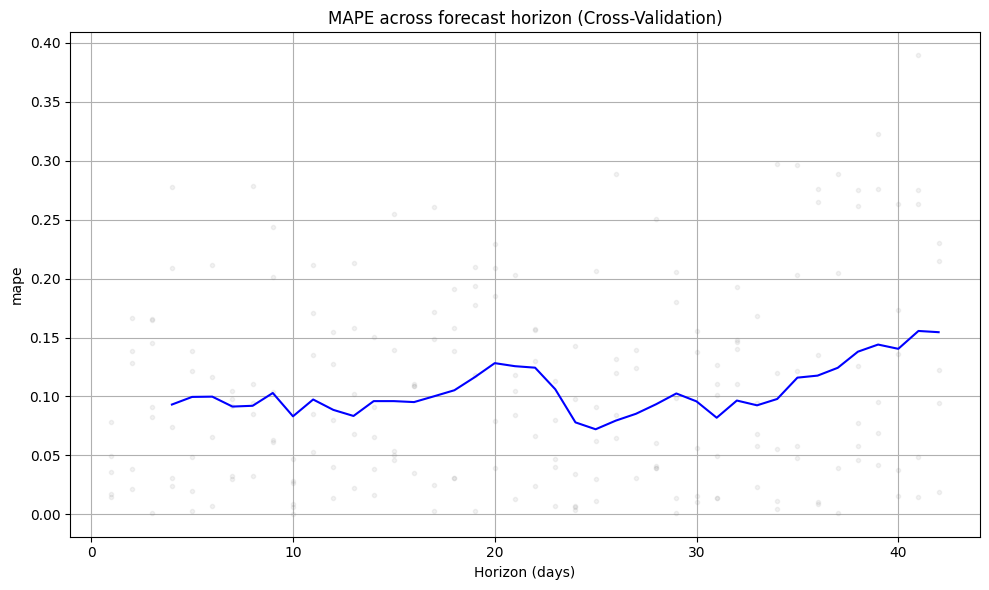

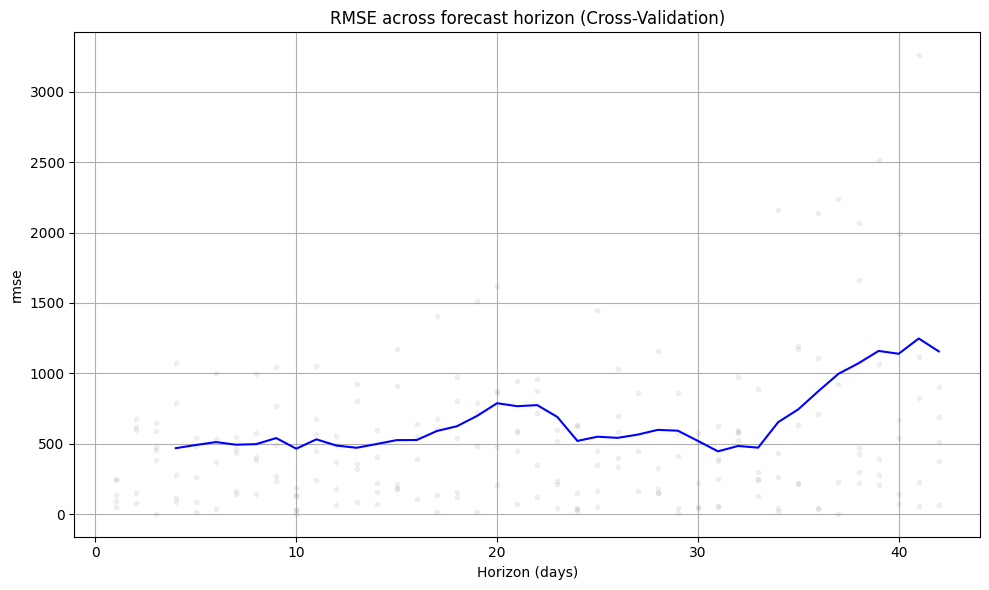

In [15]:
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.title('MAPE across forecast horizon (Cross-Validation)')
plt.tight_layout()
plt.show()

fig = plot_cross_validation_metric(df_cv, metric='rmse')
plt.title('RMSE across forecast horizon (Cross-Validation)')
plt.tight_layout()
plt.show()

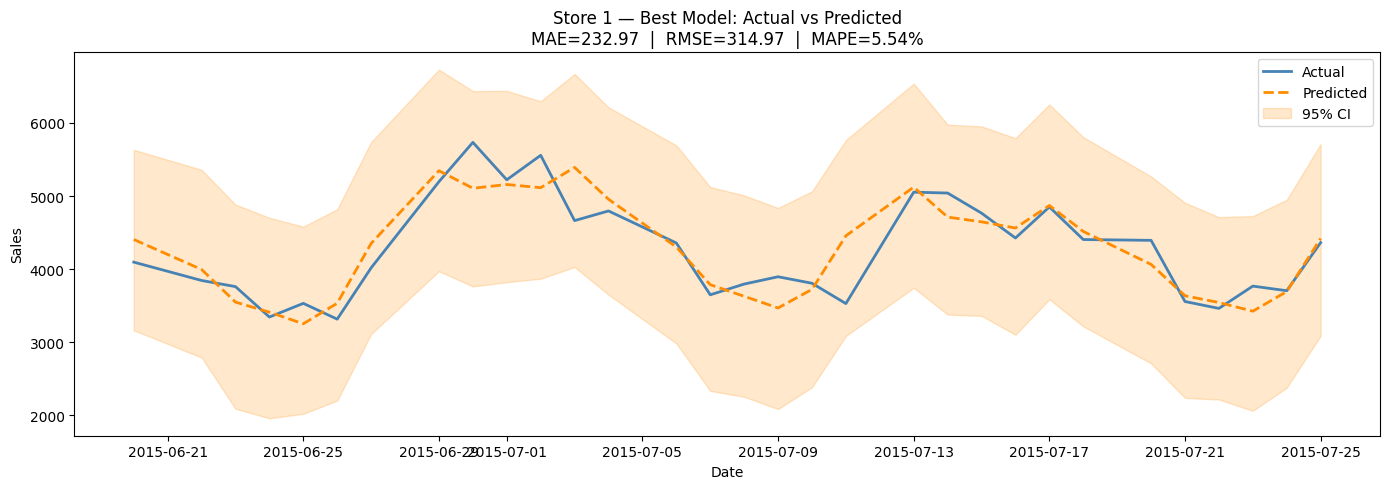

In [16]:
pred_val = forecast_optuna[forecast_optuna['ds'].isin(val_df['ds'])][
    ['ds','yhat','yhat_lower','yhat_upper']]
merged = val_df[['ds','y']].merge(pred_val, on='ds')
final_metrics = evaluate(merged['y'].values, merged['yhat'].values)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'],    label='Actual',     color='steelblue', linewidth=2)
ax.plot(merged['ds'], merged['yhat'], label='Predicted',  color='darkorange', linestyle='--', linewidth=2)
ax.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'],
                alpha=0.2, color='darkorange', label='95% CI')
ax.set_title(f"Store {STORE_ID} — Best Model: Actual vs Predicted\n"
             f"MAE={final_metrics['MAE']}  |  RMSE={final_metrics['RMSE']}  |  MAPE={final_metrics['MAPE%']}%")
ax.set_xlabel('Date'); ax.set_ylabel('Sales')
ax.legend(); plt.tight_layout(); plt.show()

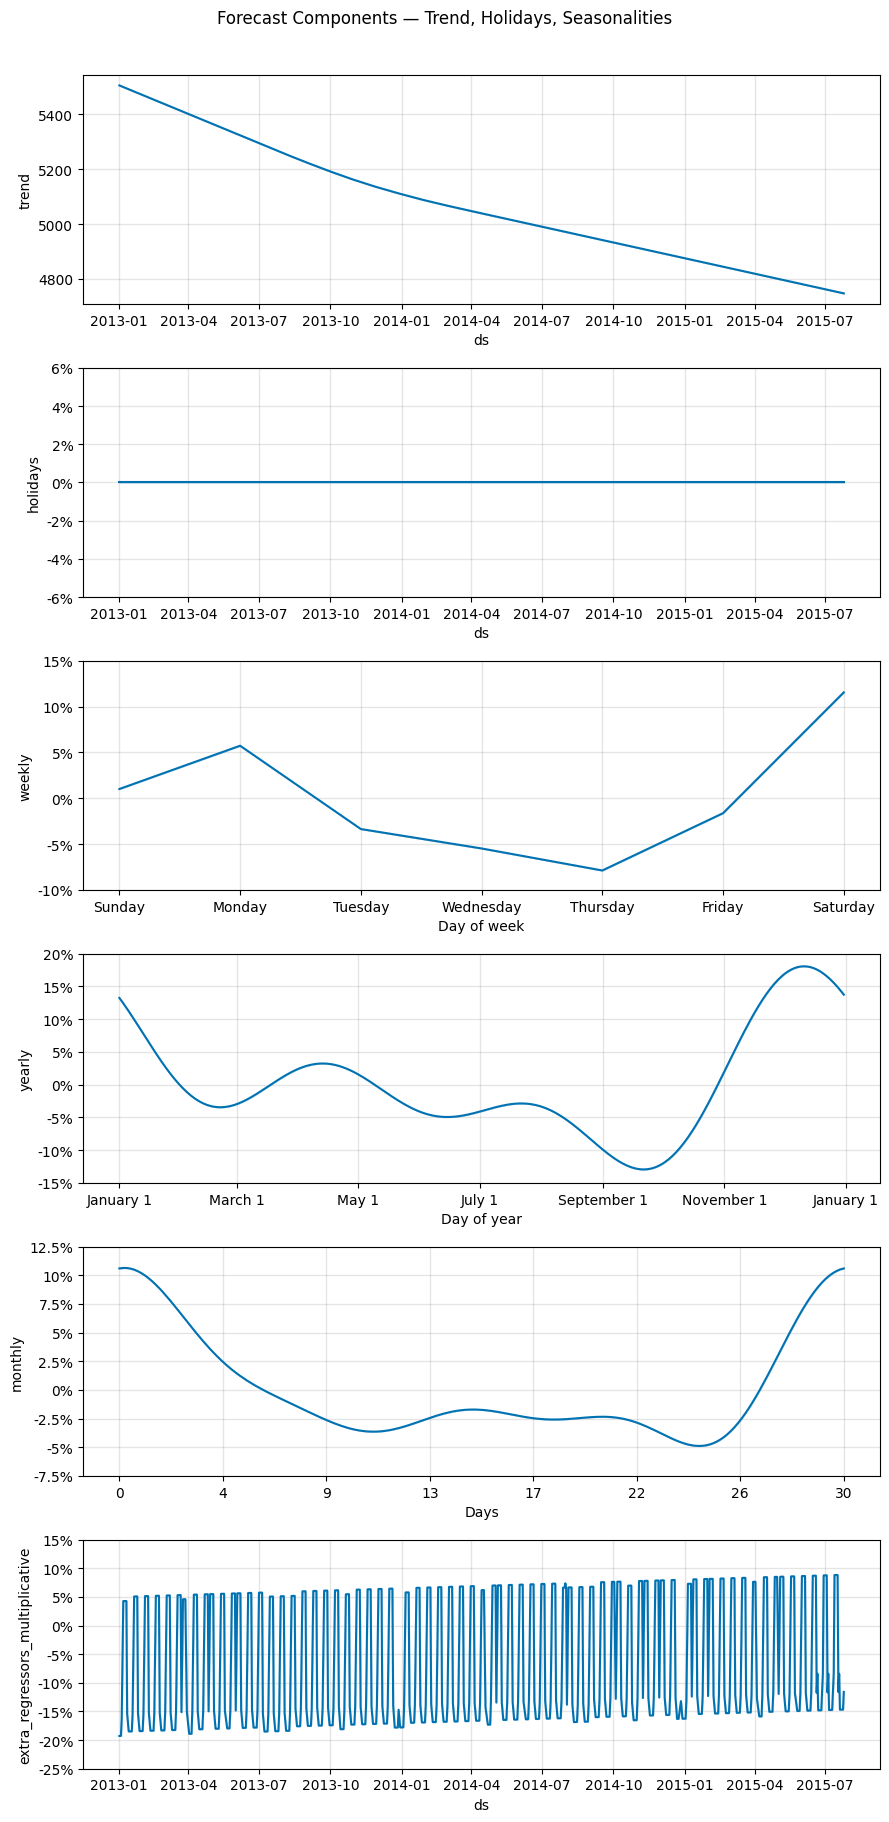

In [17]:
fig = best_model.plot_components(forecast_optuna)
plt.suptitle('Forecast Components — Trend, Holidays, Seasonalities', y=1.01)
plt.tight_layout()
plt.show()

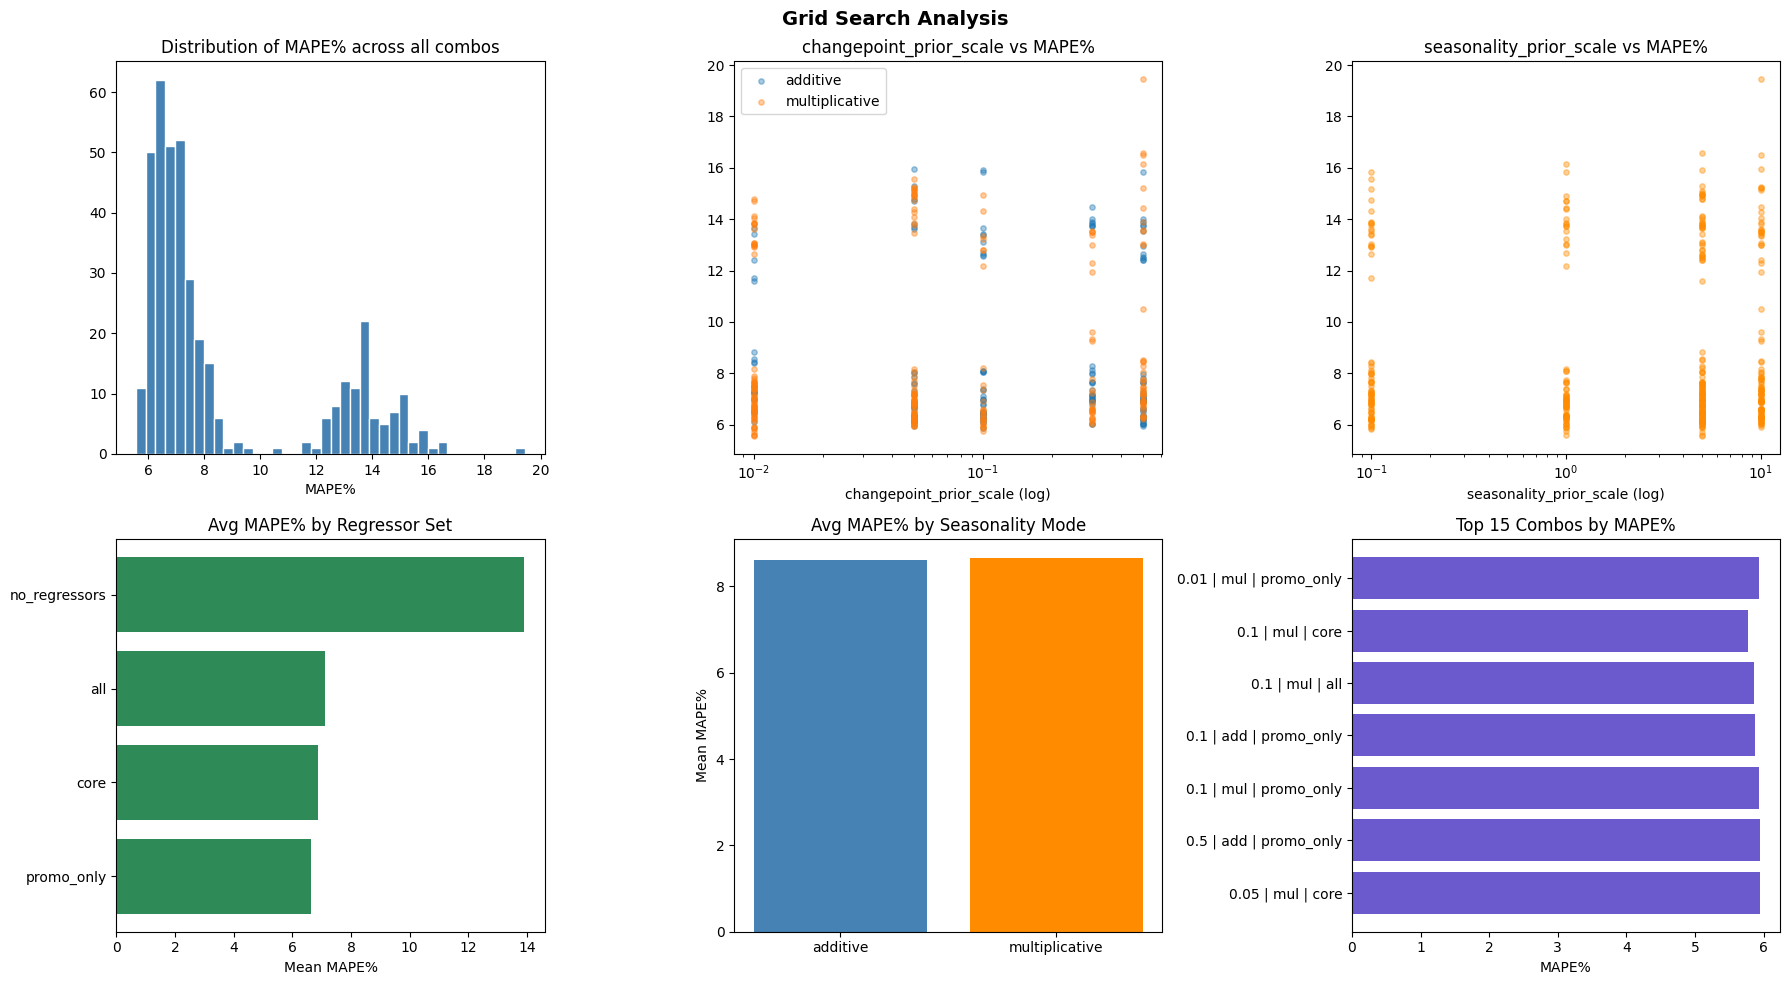

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution of MAPE
axes[0,0].hist(results_df['MAPE%'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of MAPE% across all combos')
axes[0,0].set_xlabel('MAPE%')

# 2. changepoint_prior_scale vs MAPE
for mode in ['additive','multiplicative']:
    subset = results_df[results_df['seasonality_mode'] == mode]
    axes[0,1].scatter(subset['changepoint_prior_scale'], subset['MAPE%'],
                      alpha=0.4, label=mode, s=15)
axes[0,1].set_xscale('log')
axes[0,1].set_title('changepoint_prior_scale vs MAPE%')
axes[0,1].set_xlabel('changepoint_prior_scale (log)')
axes[0,1].legend()

# 3. seasonality_prior_scale vs MAPE
axes[0,2].scatter(results_df['seasonality_prior_scale'], results_df['MAPE%'],
                  alpha=0.4, color='darkorange', s=15)
axes[0,2].set_xscale('log')
axes[0,2].set_title('seasonality_prior_scale vs MAPE%')
axes[0,2].set_xlabel('seasonality_prior_scale (log)')

# 4. Regressor set comparison
reg_perf = results_df.groupby('regressor_set')['MAPE%'].mean().sort_values()
axes[1,0].barh(reg_perf.index, reg_perf.values, color='seagreen')
axes[1,0].set_title('Avg MAPE% by Regressor Set')
axes[1,0].set_xlabel('Mean MAPE%')

# 5. Seasonality mode comparison
mode_perf = results_df.groupby('seasonality_mode')['MAPE%'].mean()
axes[1,1].bar(mode_perf.index, mode_perf.values, color=['steelblue','darkorange'])
axes[1,1].set_title('Avg MAPE% by Seasonality Mode')
axes[1,1].set_ylabel('Mean MAPE%')

# 6. Top 15 combinations
top15 = results_df.head(15).copy()
top15['label'] = (top15['changepoint_prior_scale'].round(3).astype(str) + ' | ' +
                  top15['seasonality_mode'].str[:3] + ' | ' +
                  top15['regressor_set'])
axes[1,2].barh(top15['label'], top15['MAPE%'], color='slateblue')
axes[1,2].invert_yaxis()
axes[1,2].set_title('Top 15 Combos by MAPE%')
axes[1,2].set_xlabel('MAPE%')

plt.suptitle('Grid Search Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

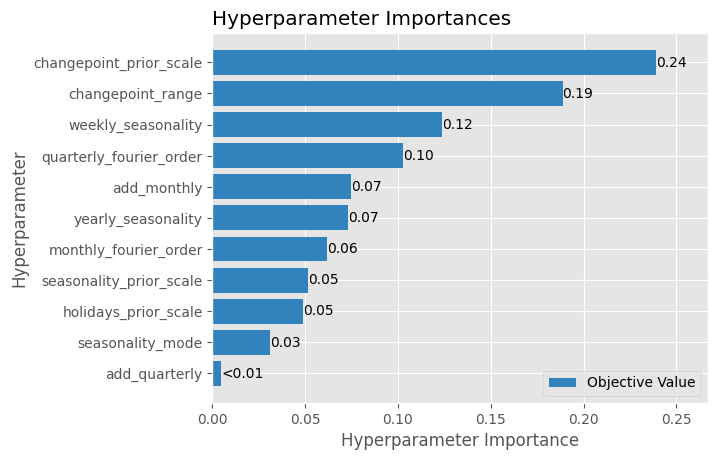

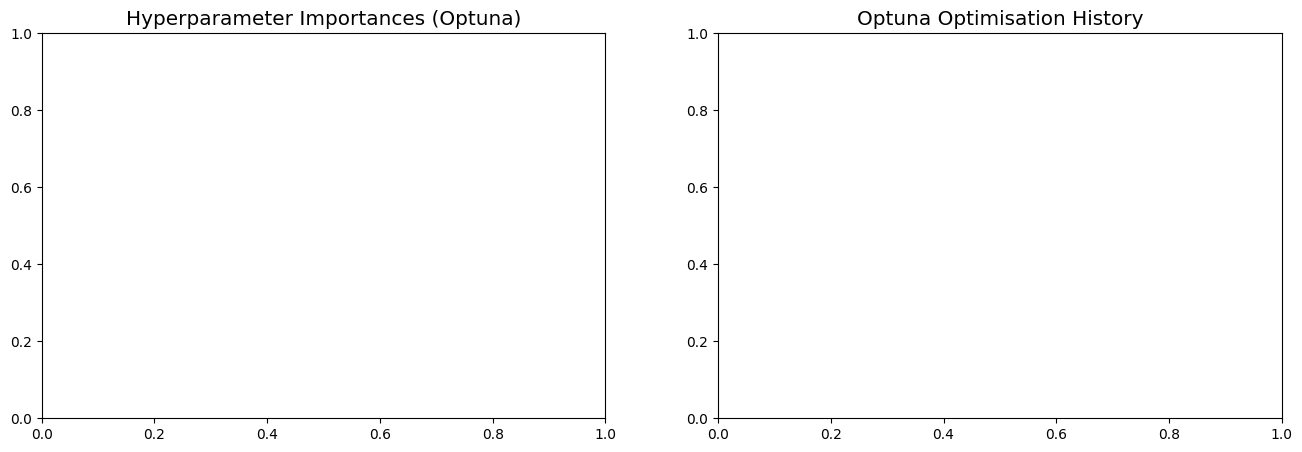

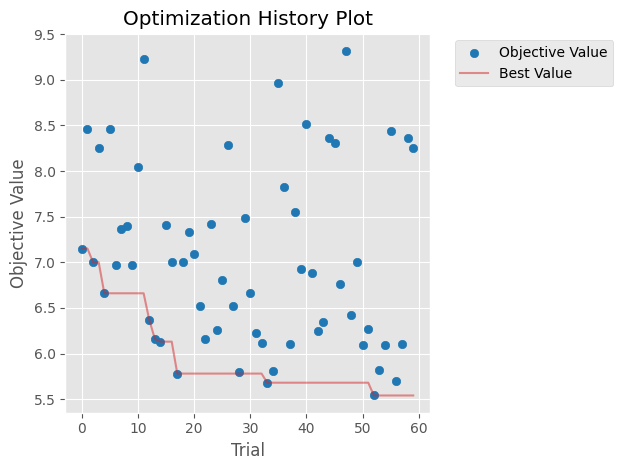

In [19]:
from optuna.visualization.matplotlib import (
    plot_param_importances,
    plot_optimization_history,
    plot_contour
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
plot_param_importances(study)
axes[0].set_title('Hyperparameter Importances (Optuna)')

plt.sca(axes[1])
plot_optimization_history(study)
axes[1].set_title('Optuna Optimisation History')

plt.tight_layout()
plt.show()

In [20]:
print("=" * 65)
print("               FINAL MODEL SUMMARY")
print("=" * 65)

print("\n📌 Grid Search Best:")
for k in ['changepoint_prior_scale','seasonality_prior_scale',
          'holidays_prior_scale','seasonality_mode',
          'changepoint_range','regressor_set']:
    print(f"   {k:35s} = {best_grid.get(k,'—')}")
print(f"   {'MAPE%':35s} = {best_grid['MAPE%']}")

print("\n📌 Optuna Best:")
for k, v in study.best_params.items():
    print(f"   {k:35s} = {v}")
print(f"   {'MAPE%':35s} = {study.best_value:.2f}%")

print("\n📌 Final Validation Metrics (Optuna model):")
for k, v in final_metrics.items():
    print(f"   {k:10s} = {v}")

print("\n📌 Cross-Validation Summary:")
print(df_perf[['horizon','mae','rmse','mape']].tail(5).to_string(index=False))
print("=" * 65)

               FINAL MODEL SUMMARY

📌 Grid Search Best:
   changepoint_prior_scale             = 0.01
   seasonality_prior_scale             = 5.0
   holidays_prior_scale                = 1.0
   seasonality_mode                    = multiplicative
   changepoint_range                   = 0.8
   regressor_set                       = promo_only
   MAPE%                               = 5.56

📌 Optuna Best:
   changepoint_prior_scale             = 0.016877874284002597
   seasonality_prior_scale             = 0.15733258913725626
   holidays_prior_scale                = 2.222031706228922
   seasonality_mode                    = multiplicative
   changepoint_range                   = 0.8341161463001697
   yearly_seasonality                  = 3
   weekly_seasonality                  = 3
   add_monthly                         = True
   monthly_fourier_order               = 4
   add_quarterly                       = False
   quarterly_fourier_order             = 6
   MAPE%                      